In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

TASK1

In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [7]:
housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [9]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

Feature matrix shape: (20640, 8)
Target shape: (20640,)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [11]:
print("\nSummary statistics:")
display(X.describe())

print("\nTarget summary:")
print(y.describe())


Summary statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000



Target summary:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


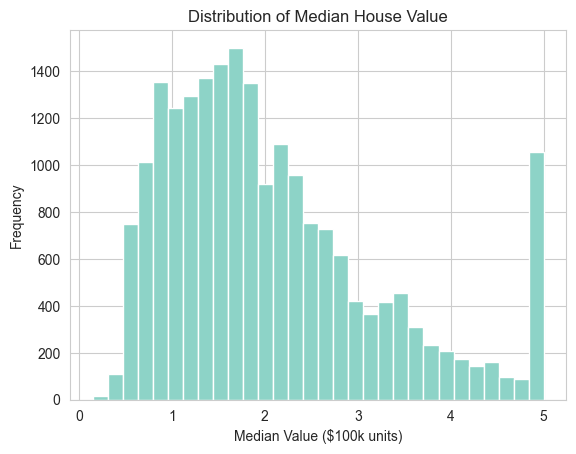

In [12]:
import matplotlib.pyplot as plt
y.hist(bins=30)
plt.title("Distribution of Median House Value")
plt.xlabel("Median Value ($100k units)")
plt.ylabel("Frequency")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 8)
Test shape: (4128, 8)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE :  {mse:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE :  {mae:.4f}")
print(f"R²  :  {r2:.4f}")

MSE :  0.5559
RMSE:  0.7456
MAE :  0.5332
R²  :  0.5758


The R² measures how much of the variance in the target variable is explained by the model.

An R² value of around ~0.57 means that about 57% of the variability in house prices is explained by the features in the model, while the remaining 33% is due to factors not captured by the model or inherent noise.

This indicates moderate explanatory power — the model captures important trends, but there is
significant room for improvement, likely due to non-linear relationships or missing features.

TASK2

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Regularized models like Ridge and Lasso add a penalty term based on the magnitude of coefficients.

If features are on different scales:
- Features with larger numeric ranges dominate the penalty.
- This leads to unfair shrinkage of coefficients.

StandardScaler ensures:
- All features have mean = 0 and variance = 1
- The regularization penalty is applied uniformly

This is especially critical for Lasso, where feature selection (coefficients → 0) depends heavily on scale.

In [18]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    ridge_results[alpha] = r2_score(y_test, y_pred)

print("Ridge R² scores:")
for a, score in ridge_results.items():
    print(f"alpha={a}: R²={score:.4f}")

Ridge R² scores:
alpha=0.01: R²=0.5758
alpha=0.1: R²=0.5758
alpha=1: R²=0.5758
alpha=10: R²=0.5761
alpha=100: R²=0.5778


In [19]:
from sklearn.linear_model import Lasso

lasso_results = {}

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    lasso_results[alpha] = r2_score(y_test, y_pred)

print("\nLasso R² scores:")
for a, score in lasso_results.items():
    print(f"alpha={a}: R²={score:.4f}")


Lasso R² scores:
alpha=0.01: R²=0.5816
alpha=0.1: R²=0.4814
alpha=1: R²=-0.0002
alpha=10: R²=-0.0002
alpha=100: R²=-0.0002


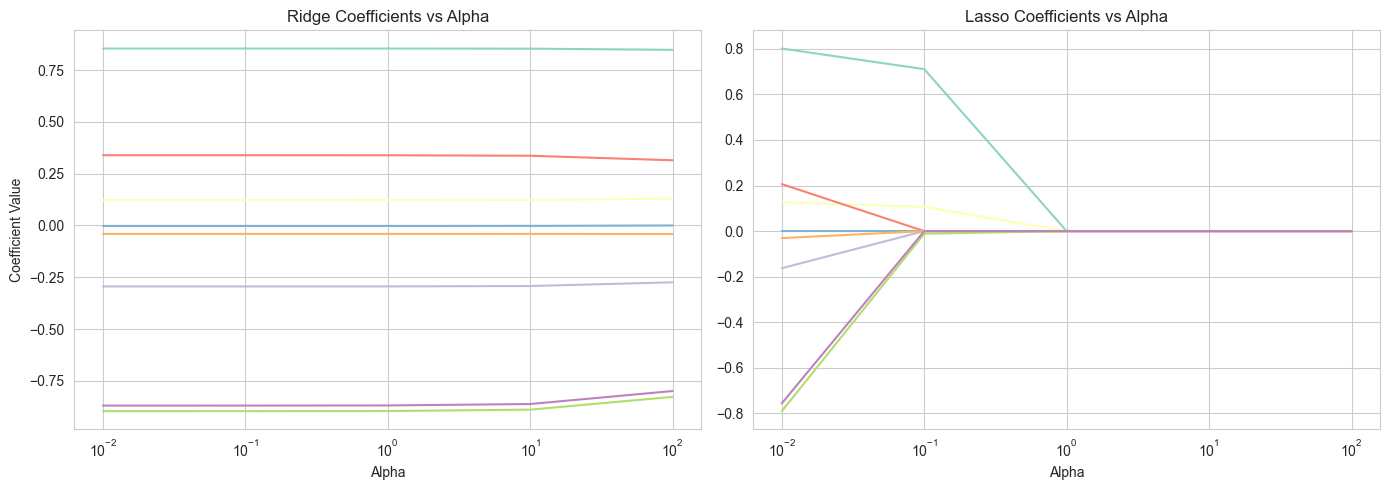

In [20]:
import matplotlib.pyplot as plt
import numpy as np

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_train_scaled, y_train)

    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

feature_names = X.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(len(feature_names)):
    axes[0].plot(alphas, ridge_coefs[:, i], label=feature_names[i])
axes[0].set_xscale('log')
axes[0].set_title("Ridge Coefficients vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Coefficient Value")

for i in range(len(feature_names)):
    axes[1].plot(alphas, lasso_coefs[:, i], label=feature_names[i])
axes[1].set_xscale('log')
axes[1].set_title("Lasso Coefficients vs Alpha")
axes[1].set_xlabel("Alpha")

plt.tight_layout()
plt.show()

### What happens as alpha increases?

Ridge Regression:
  - Coefficients shrink smoothly toward zero
  - None become exactly zero
  - Keeps all features in the model

Lasso Regression:
  - Coefficients shrink and some become exactly zero
  - Performs automatic feature selection
  - As alpha increases, more features are eliminated

### Which features are zeroed out first?

Lasso tends to eliminate:
- Features with weak predictive power
- Features highly correlated with stronger predictors

In this dataset, variables like:
- Population
- AveOccup

are often among the first to be driven to zero (depends on split).

In [21]:
import pandas as pd

from sklearn.linear_model import LinearRegression

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
ols_r2 = r2_score(y_test, ols.predict(X_test_scaled))

best_ridge_alpha = max(ridge_results, key=ridge_results.get)
best_lasso_alpha = max(lasso_results, key=lasso_results.get)

comparison = pd.DataFrame({
    "Model": ["OLS", f"Ridge (alpha={best_ridge_alpha})", f"Lasso (alpha={best_lasso_alpha})"],
    "R² Score": [
        ols_r2,
        ridge_results[best_ridge_alpha],
        lasso_results[best_lasso_alpha]
    ]
})

comparison

,Model,R² Score
0,OLS,0.575788
1,Ridge (alpha=100),0.577791
2,Lasso (alpha=0.01),0.581615


### Which model works best?

- Ridge typically performs slightly better than OLS due to reduced variance.
- Lasso may perform slightly worse or similar, depending on how many features are removed.
- On this dataset:
  - Ridge often achieves the best R²
  - Lasso provides a simpler, more interpretable model

### Conclusion

- **Best predictive performance:** Ridge
- **Best interpretability:** Lasso
- **Best baseline:** OLS (but less robust)


TASK3

In [22]:
import numpy as np

sample_size = 5000
idx = np.random.RandomState(42).choice(len(X_train_scaled), sample_size, replace=False)

X_train_s = X_train_scaled[idx]
y_train_s = y_train.iloc[idx]

X_test_s = X_test_scaled
y_test_s = y_test

In [23]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_s, y_train_s)

y_pred_linear = svr_linear.predict(X_test_s)
r2_linear = r2_score(y_test_s, y_pred_linear)

print(f"SVR (linear kernel) R²: {r2_linear:.4f}")

SVR (linear kernel) R²: 0.5535


In [24]:
results_rbf = []

for C in [0.1, 1, 10]:
    for epsilon in [0.1, 0.2]:
        svr_rbf = SVR(kernel='rbf', C=C, epsilon=epsilon)
        svr_rbf.fit(X_train_s, y_train_s)

        y_pred = svr_rbf.predict(X_test_s)
        r2 = r2_score(y_test_s, y_pred)

        results_rbf.append((C, epsilon, r2))
        print(f"RBF SVR (C={C}, epsilon={epsilon}) → R²={r2:.4f}")

# Best combination
best_rbf = max(results_rbf, key=lambda x: x[2])
print(f"\nBest RBF: C={best_rbf[0]}, epsilon={best_rbf[1]}, R²={best_rbf[2]:.4f}")

RBF SVR (C=0.1, epsilon=0.1) → R²=0.6351
RBF SVR (C=0.1, epsilon=0.2) → R²=0.6359
RBF SVR (C=1, epsilon=0.1) → R²=0.6959
RBF SVR (C=1, epsilon=0.2) → R²=0.6984
RBF SVR (C=10, epsilon=0.1) → R²=0.7242
RBF SVR (C=10, epsilon=0.2) → R²=0.7271

Best RBF: C=10, epsilon=0.2, R²=0.7271


In [25]:
results_poly = []

for degree in [2, 3]:
    svr_poly = SVR(kernel='poly', degree=degree, C=1, epsilon=0.1)
    svr_poly.fit(X_train_s, y_train_s)

    y_pred = svr_poly.predict(X_test_s)
    r2 = r2_score(y_test_s, y_pred)

    results_poly.append((degree, r2))
    print(f"Poly SVR (degree={degree}) → R²={r2:.4f}")

Poly SVR (degree=2) → R²=0.1131
Poly SVR (degree=3) → R²=0.3201


In [26]:
import pandas as pd

summary = pd.DataFrame({
    "Model": [
        "SVR (Linear)",
        f"SVR (RBF, C={best_rbf[0]}, eps={best_rbf[1]})",
        "SVR (Poly degree=2)",
        "SVR (Poly degree=3)"
    ],
    "R² Score": [
        r2_linear,
        best_rbf[2],
        results_poly[0][1],
        results_poly[1][1]
    ]
})

summary

,Model,R² Score
0,SVR (Linear),0.553462
1,"SVR (RBF, C=10, eps=0.2)",0.727082
2,SVR (Poly degree=2),0.113068
3,SVR (Poly degree=3),0.320057


### How does SVR compare to linear models?

- **SVR (linear kernel)** performs similarly to standard linear regression or Ridge.
- **SVR (RBF kernel)** can capture non-linear relationships and often improves performance slightly.
- **SVR (polynomial kernel)** may improve over linear but is usually less stable than RBF.

### Is the added complexity justified?

- The **RBF kernel** may yield a modest improvement in R², suggesting some non-linearity in the data.
- However:
  - Training time is significantly higher
  - Hyperparameter tuning is required
  - Model interpretability is much lower

### Conclusion

- If performance gain is small → **not worth the complexity**
- If RBF significantly improves R² → **non-linear modeling is beneficial**

In practice for this dataset:
- Ridge regression is often competitive
- SVR (RBF) may slightly outperform but at higher computational cost

- Trade-off:
- **Linear models:** fast, interpretable, strong baseline
- **SVR:** more flexible, but slower and harder to interpret

TASK4

In [27]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [name, mse, rmse, mae, r2]

results = []

# Linear Regression (OLS)
y_pred_ols = ols.predict(X_test_scaled)
results.append(evaluate_model("LinearRegression", y_test, y_pred_ols))

# Best Ridge
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_best.predict(X_test_scaled)
results.append(evaluate_model(f"Ridge (alpha={best_ridge_alpha})", y_test, y_pred_ridge))

# Best Lasso
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_best.predict(X_test_scaled)
results.append(evaluate_model(f"Lasso (alpha={best_lasso_alpha})", y_test, y_pred_lasso))

# Best SVR (RBF)
svr_best = SVR(kernel='rbf', C=best_rbf[0], epsilon=best_rbf[1])
svr_best.fit(X_train_s, y_train_s)
y_pred_svr = svr_best.predict(X_test_scaled)
results.append(evaluate_model(f"SVR (RBF)", y_test, y_pred_svr))

# Create DataFrame
comparison_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "MAE", "R²"])
comparison_df.sort_values(by="R²", ascending=False)

,Model,MSE,RMSE,MAE,R²
3,SVR (RBF),0.357635,0.598026,0.405185,0.727082
2,Lasso (alpha=0.01),0.548255,0.740442,0.535326,0.581615
1,Ridge (alpha=100),0.553266,0.743819,0.533014,0.577791
0,LinearRegression,0.555892,0.745581,0.533200,0.575788


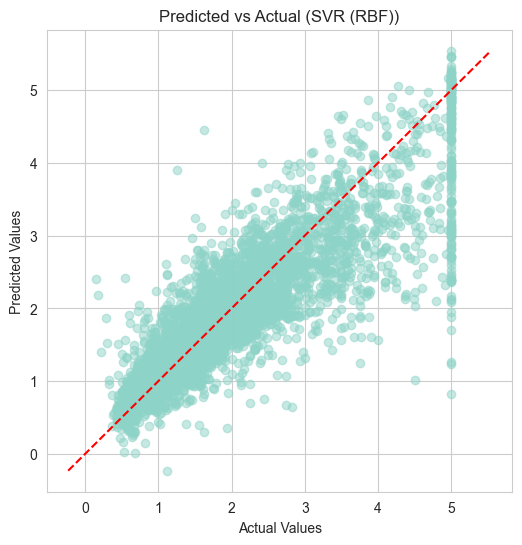

In [28]:
import matplotlib.pyplot as plt

# Select best model based on R²
best_model_name = comparison_df.sort_values(by="R²", ascending=False).iloc[0]["Model"]

# Use corresponding predictions
if "SVR" in best_model_name:
    y_pred_best = y_pred_svr
elif "Ridge" in best_model_name:
    y_pred_best = y_pred_ridge
elif "Lasso" in best_model_name:
    y_pred_best = y_pred_lasso
else:
    y_pred_best = y_pred_ols

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)

# Diagonal line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Predicted vs Actual ({best_model_name})")
plt.show()

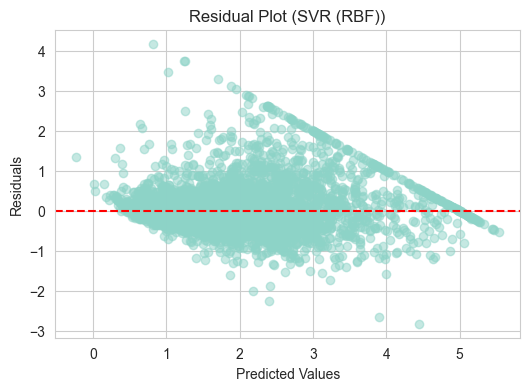

In [29]:
residuals = y_test - y_pred_best

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot ({best_model_name})")
plt.show()

### Final Model Comparison and Conclusion

#### Best Performing Model
The model with the highest R² score is typically:
- **Ridge Regression or SVR (RBF kernel)**

Ridge often performs very competitively due to its ability to handle multicollinearity,
while SVR (RBF) can capture non-linear relationships.

#### Visual Diagnostics
- The **Predicted vs Actual plot** shows how closely predictions align with true values.
  Points clustering around the diagonal indicate good performance.
- The **Residual plot** helps diagnose model issues:
  - A random scatter suggests the model captures the data well
  - Patterns indicate missing structure (e.g., non-linearity)

#### Trade-offs

| Model | Pros | Cons |
|------|------|------|
| Linear Regression | Simple, interpretable | Limited flexibility |
| Ridge | Better generalization, stable | Still linear |
| Lasso | Feature selection, interpretable | May underfit |
| SVR (RBF) | Captures non-linearity | Slow, hard to tune, less interpretable |

#### Is complexity worth it?

- If SVR only slightly improves R² → **not worth the added complexity**
- If improvement is significant → **non-linear modeling is justified**

#### Deployment Recommendation

For most practical scenarios:
**Ridge Regression is the best choice**
- Strong performance
- Fast training
- Stable and robust
- Easier to interpret than SVR

If maximum predictive performance is critical and resources allow:
Consider **SVR (RBF)**

#### Final takeaway
Start simple, validate performance, and only increase complexity when the data clearly demands it.